<a href="https://colab.research.google.com/github/SKSAHILAKHTAR1/AI-Powered-SDR-Laboratory/blob/main/Uniform_quantization_PCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

n = 2 bits | L =   4 | Delta = 0.5000 | Measured SQNR =  12.81 dB | Theoretical SQNR =  13.80 dB | MSE = 0.026206
n = 3 bits | L =   8 | Delta = 0.2500 | Measured SQNR =  19.06 dB | Theoretical SQNR =  19.82 dB | MSE = 0.006202
n = 4 bits | L =  16 | Delta = 0.1250 | Measured SQNR =  25.23 dB | Theoretical SQNR =  25.84 dB | MSE = 0.001501
n = 6 bits | L =  64 | Delta = 0.0312 | Measured SQNR =  36.34 dB | Theoretical SQNR =  37.88 dB | MSE = 0.000116
n = 8 bits | L = 256 | Delta = 0.0078 | Measured SQNR =  48.72 dB | Theoretical SQNR =  49.92 dB | MSE = 0.000007

Sample PCM Encoding (First 10 samples for n=3):
Sample 00: x(t) = +0.000 -> Index = 4 -> PCM Code = 100
Sample 01: x(t) = +0.031 -> Index = 4 -> PCM Code = 100
Sample 02: x(t) = +0.063 -> Index = 4 -> PCM Code = 100
Sample 03: x(t) = +0.094 -> Index = 4 -> PCM Code = 100
Sample 04: x(t) = +0.125 -> Index = 4 -> PCM Code = 100
Sample 05: x(t) = +0.156 -> Index = 4 -> PCM Code = 100
Sample 06: x(t) = +0.187 -> Index = 4 -> PCM 

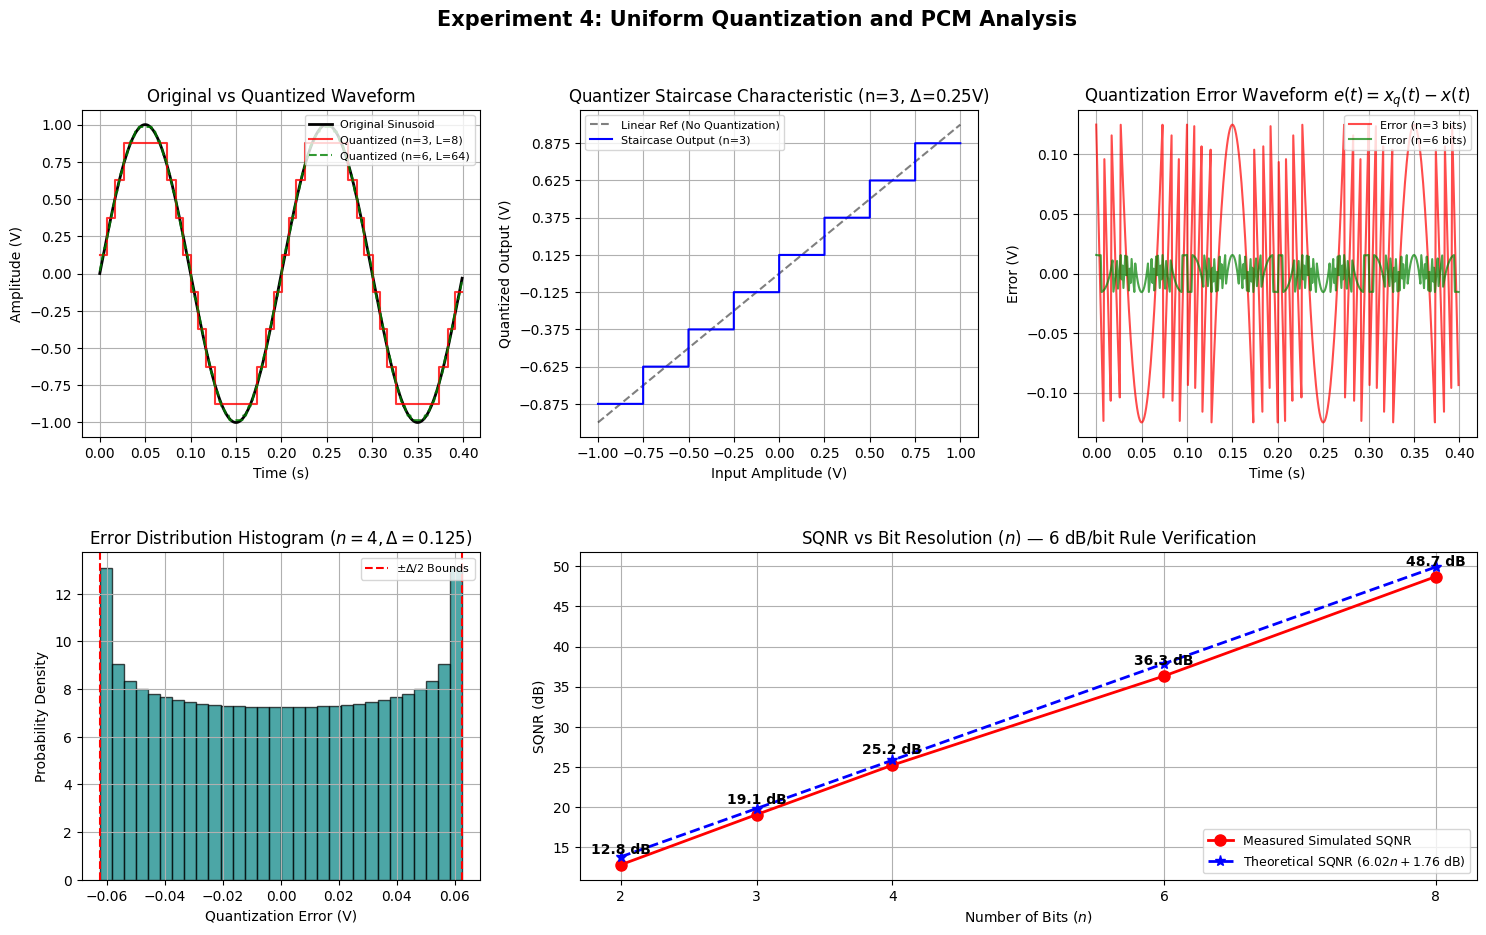

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# 1. SIGNAL DEFINITION & UNIFORM PCM QUANTIZER
# ====================================================================
f_sig = 5          # Frequency of input sinusoid (Hz)
fs = 1000          # Sampling frequency (Hz)
t_duration = 0.4   # Duration (seconds)
t = np.linspace(0, t_duration, int(fs * t_duration), endpoint=False)

# Normalized sinusoid in range [-1, 1]
x_analog = np.sin(2 * np.pi * f_sig * t)
x_min, x_max = -1.0, 1.0

def uniform_pcm_quantizer(x, n_bits, x_min=-1.0, x_max=1.0):
    """
    Uniform mid-rise quantizer from first principles.
    Returns: quantized signal, quantization error, integer indices,
             binary codewords, step size (Delta), and representation levels.
    """
    L = 2 ** n_bits
    Delta = (x_max - x_min) / L

    # Mid-rise representation levels (centers of each interval)
    q_levels = x_min + (np.arange(L) + 0.5) * Delta

    # Compute indices: Map continuous amplitudes to bins [0, L-1]
    indices = np.floor((x - x_min) / Delta).astype(int)
    indices = np.clip(indices, 0, L - 1)  # Handle boundary condition x == x_max

    # Reconstruct quantized values
    x_quantized = q_levels[indices]
    error = x_quantized - x

    # Generate PCM Binary Codewords (zero-padded to n bits)
    pcm_codewords = [np.binary_repr(idx, width=n_bits) for idx in indices]

    # Mandatory Validation Checks
    assert np.all((indices >= 0) & (indices < L)), f"Validation Failed: Index out of bounds for n={n_bits}"
    assert all(len(code) == n_bits for code in pcm_codewords), f"Validation Failed: Codeword length mismatch for n={n_bits}"

    return x_quantized, error, indices, pcm_codewords, Delta, q_levels

# ====================================================================
# 2. EVALUATION ACROSS BIT RESOLUTIONS (2, 3, 4, 6, 8 bits)
# ====================================================================
bit_rates = [2, 3, 4, 6, 8]
practical_sqnr = []
theoretical_sqnr = []
mse_list = []

for n in bit_rates:
    x_q, err, idxs, pcm, Delta, _ = uniform_pcm_quantizer(x_analog, n, x_min, x_max)

    # Measured Signal & Noise Power
    p_signal = np.mean(x_analog ** 2)
    mse = np.mean(err ** 2)
    mse_list.append(mse)

    sqnr_meas = 10 * np.log10(p_signal / mse)
    sqnr_theo = 6.02 * n + 1.76

    practical_sqnr.append(sqnr_meas)
    theoretical_sqnr.append(sqnr_theo)

    print(f"n = {n} bits | L = {2**n:3d} | Delta = {Delta:.4f} | Measured SQNR = {sqnr_meas:6.2f} dB | Theoretical SQNR = {sqnr_theo:6.2f} dB | MSE = {mse:.6f}")

# Display Sample PCM Codewords for n=3 bits (First 10 samples)
_, _, sample_idx, sample_pcm, _, _ = uniform_pcm_quantizer(x_analog, 3, x_min, x_max)
print("\nSample PCM Encoding (First 10 samples for n=3):")
for i in range(10):
    print(f"Sample {i:02d}: x(t) = {x_analog[i]:+0.3f} -> Index = {sample_idx[i]} -> PCM Code = {sample_pcm[i]}")

# ====================================================================
# 3. COMPREHENSIVE VISUALIZATION (ERROR & WARNING FREE)
# ====================================================================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25)
fig.suptitle("Experiment 4: Uniform Quantization and PCM Analysis", fontsize=15, fontweight='bold')

# Plot 1: Waveforms (Original vs Quantized for n=3 and n=6)
ax1 = fig.add_subplot(gs[0, 0])
x_q3, _, _, _, _, _ = uniform_pcm_quantizer(x_analog, 3, x_min, x_max)
x_q6, _, _, _, _, _ = uniform_pcm_quantizer(x_analog, 6, x_min, x_max)
ax1.plot(t, x_analog, 'k-', label='Original Sinusoid', lw=2)
ax1.step(t, x_q3, 'r-', label='Quantized (n=3, L=8)', where='mid', alpha=0.8)
ax1.plot(t, x_q6, 'g--', label='Quantized (n=6, L=64)', alpha=0.8)
ax1.set_title("Original vs Quantized Waveform")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude (V)")
ax1.grid(True)
ax1.legend(loc='upper right', fontsize=8)

# Plot 2: Quantizer Transfer Characteristic (Staircase) for n=3 bits
ax2 = fig.add_subplot(gs[0, 1])
x_sweep = np.linspace(-1.0, 1.0, 1000)
x_q_sweep, _, _, _, Delta3, q_levels3 = uniform_pcm_quantizer(x_sweep, 3, x_min, x_max)
ax2.plot(x_sweep, x_sweep, 'k--', label='Linear Ref (No Quantization)', alpha=0.5)
ax2.step(x_sweep, x_q_sweep, 'b-', label='Staircase Output (n=3)', where='mid')
ax2.set_yticks(q_levels3)
ax2.set_title(rf"Quantizer Staircase Characteristic (n=3, $\Delta$={Delta3:.2f}V)")
ax2.set_xlabel("Input Amplitude (V)")
ax2.set_ylabel("Quantized Output (V)")
ax2.grid(True)
ax2.legend(loc='upper left', fontsize=8)

# Plot 3: Error Waveform Comparison
ax3 = fig.add_subplot(gs[0, 2])
_, err3, _, _, _, _ = uniform_pcm_quantizer(x_analog, 3, x_min, x_max)
_, err6, _, _, _, _ = uniform_pcm_quantizer(x_analog, 6, x_min, x_max)
ax3.plot(t, err3, 'r-', label='Error (n=3 bits)', alpha=0.7)
ax3.plot(t, err6, 'g-', label='Error (n=6 bits)', alpha=0.7)
ax3.set_title(r"Quantization Error Waveform $e(t) = x_q(t) - x(t)$")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Error (V)")
ax3.grid(True)
ax3.legend(loc='upper right', fontsize=8)

# Plot 4: Error Histogram (Uniformity Check for n=4 bits)
ax4 = fig.add_subplot(gs[1, 0])
x_dense = np.sin(2 * np.pi * f_sig * np.linspace(0, 2, 50000))
_, err_dense, _, _, Delta4, _ = uniform_pcm_quantizer(x_dense, 4, x_min, x_max)
ax4.hist(err_dense, bins=30, density=True, color='teal', edgecolor='black', alpha=0.7)
ax4.axvline(-Delta4/2, color='r', linestyle='--', label=r'$\pm \Delta/2$ Bounds')
ax4.axvline(Delta4/2, color='r', linestyle='--')
ax4.set_title(r"Error Distribution Histogram ($n=4, \Delta=0.125$)")
ax4.set_xlabel("Quantization Error (V)")
ax4.set_ylabel("Probability Density")
ax4.grid(True)
ax4.legend(loc='upper right', fontsize=8)

# Plot 5: SQNR vs Bits (Theoretical vs Measured)
ax5 = fig.add_subplot(gs[1, 1:])
ax5.plot(bit_rates, practical_sqnr, 'ro-', lw=2, markersize=8, label='Measured Simulated SQNR')
ax5.plot(bit_rates, theoretical_sqnr, 'b*--', lw=2, markersize=8, label=r'Theoretical SQNR ($6.02n + 1.76$ dB)')
for n_val, p_sqnr in zip(bit_rates, practical_sqnr):
    ax5.annotate(f"{p_sqnr:.1f} dB", (n_val, p_sqnr), textcoords="offset points", xytext=(0, 8), ha='center', fontweight='bold')
ax5.set_title(r"SQNR vs Bit Resolution ($n$) — 6 dB/bit Rule Verification")
ax5.set_xlabel("Number of Bits ($n$)")
ax5.set_ylabel("SQNR (dB)")
ax5.set_xticks(bit_rates)
ax5.grid(True)
ax5.legend(loc='lower right', fontsize=9)

plt.show()